# Proyecto Final
**Diplomado en Analítica de Datos con Python**

| Campo | Detalle |
|---|---|
| **Nombre** | Karina Correa |
| **Dataset** | Bird Migration Dataset · [Kaggle](https://www.kaggle.com/datasets/sahirmaharajj/bird-migration-dataset-data-visualization-eda) |
| **Entorno** | Jupyter Notebook / Local |
| **Link notebook** | *(pegar link)* |
| **Dashboard** | Tableau Public |
| **Link dashboard** | *(pegar link)* |
| **Pregunta de negocio** | ¿Qué factores ambientales y de vuelo están asociados con el éxito migratorio de las aves, y cómo varía ese éxito a lo largo del año? |

## Fase 1 · Exploración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("https://raw.githubusercontent.com/KARCOR/diplomado-anal-tica-datos/main/bird_migration_with_origin_destination.csv")

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
display(df.head(3))
print("\nValores nulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Filas: 10000  |  Columnas: 43


,Bird_ID,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,...,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin,Destination
0,B1000,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,...,Storm,Researcher_A,27.0,Failed,No,102,56,Low,"11.906566441337574, -169.37825068830264","30.377646664303118, -21.36687925839209"
1,B1001,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,...,Injury,Researcher_C,14.2,Successful,Yes,118,61,Low,"62.301545854189925, -111.47506945435978","39.92109196071499, 47.96343632717577"
2,B1002,Hawk,South America,Mountain,Stormy,Avoid Predators,87.861164,-78.727327,66.990980,19.448466,...,Lost Signal,Researcher_B,16.1,Failed,No,41,71,High,"87.86116387126651, -78.72732718179907","66.9909803844028, 19.44846614106183"



Valores nulos por columna:
Interrupted_Reason    1981
dtype: int64

Filas duplicadas: 0


**Observaciones:** 10,000 registros con 43 variables de vuelo, clima y comportamiento.
El único campo con nulos es `Interrupted_Reason` (1,981), lo cual es esperado: corresponde
a aves cuya migración no fue interrumpida. No hay duplicados.

In [2]:
variables_numericas = [
    "Flight_Distance_km", "Flight_Duration_hours", "Average_Speed_kmph",
    "Max_Altitude_m", "Temperature_C", "Wind_Speed_kmph",
    "Humidity_%", "Rest_Stops", "Flock_Size"
]

desc = df[variables_numericas].describe().T.round(2)
desc["moda"] = df[variables_numericas].mode().iloc[0].round(2)
display(desc)

for col in ["Species", "Habitat"]:
    display(df[col].value_counts().rename(col))

,count,mean,std,min,25%,50%,75%,max,moda
Flight_Distance_km,10000.0,2504.04,499.72,527.70,2169.63,2511.15,2841.45,4428.32,2116.93
Flight_Duration_hours,10000.0,49.99,10.03,12.60,43.20,50.05,56.80,91.00,50.60
Average_Speed_kmph,10000.0,49.95,5.09,30.43,46.53,50.04,53.36,68.95,51.50
Max_Altitude_m,10000.0,5504.81,2595.29,1000.00,3277.75,5521.00,7740.25,9999.00,2091.00
Temperature_C,10000.0,12.57,13.07,-10.00,1.20,12.50,24.00,35.00,7.10
Wind_Speed_kmph,10000.0,30.36,17.32,0.00,15.30,30.50,45.40,60.00,47.00
Humidity_%,10000.0,54.22,25.87,10.00,32.00,54.00,77.00,99.00,62.00
Rest_Stops,10000.0,7.38,4.02,1.00,4.00,7.00,11.00,14.00,3.00
Flock_Size,10000.0,248.71,144.94,1.00,124.00,248.00,376.00,499.00,24.00


Species
Hawk       1464
Stork      1439
Warbler    1429
Goose      1428
Eagle      1426
Swallow    1423
Crane      1391
Name: Species, dtype: int64

Habitat
Wetland      1699
Coastal      1680
Urban        1674
Forest       1663
Mountain     1647
Grassland    1637
Name: Habitat, dtype: int64

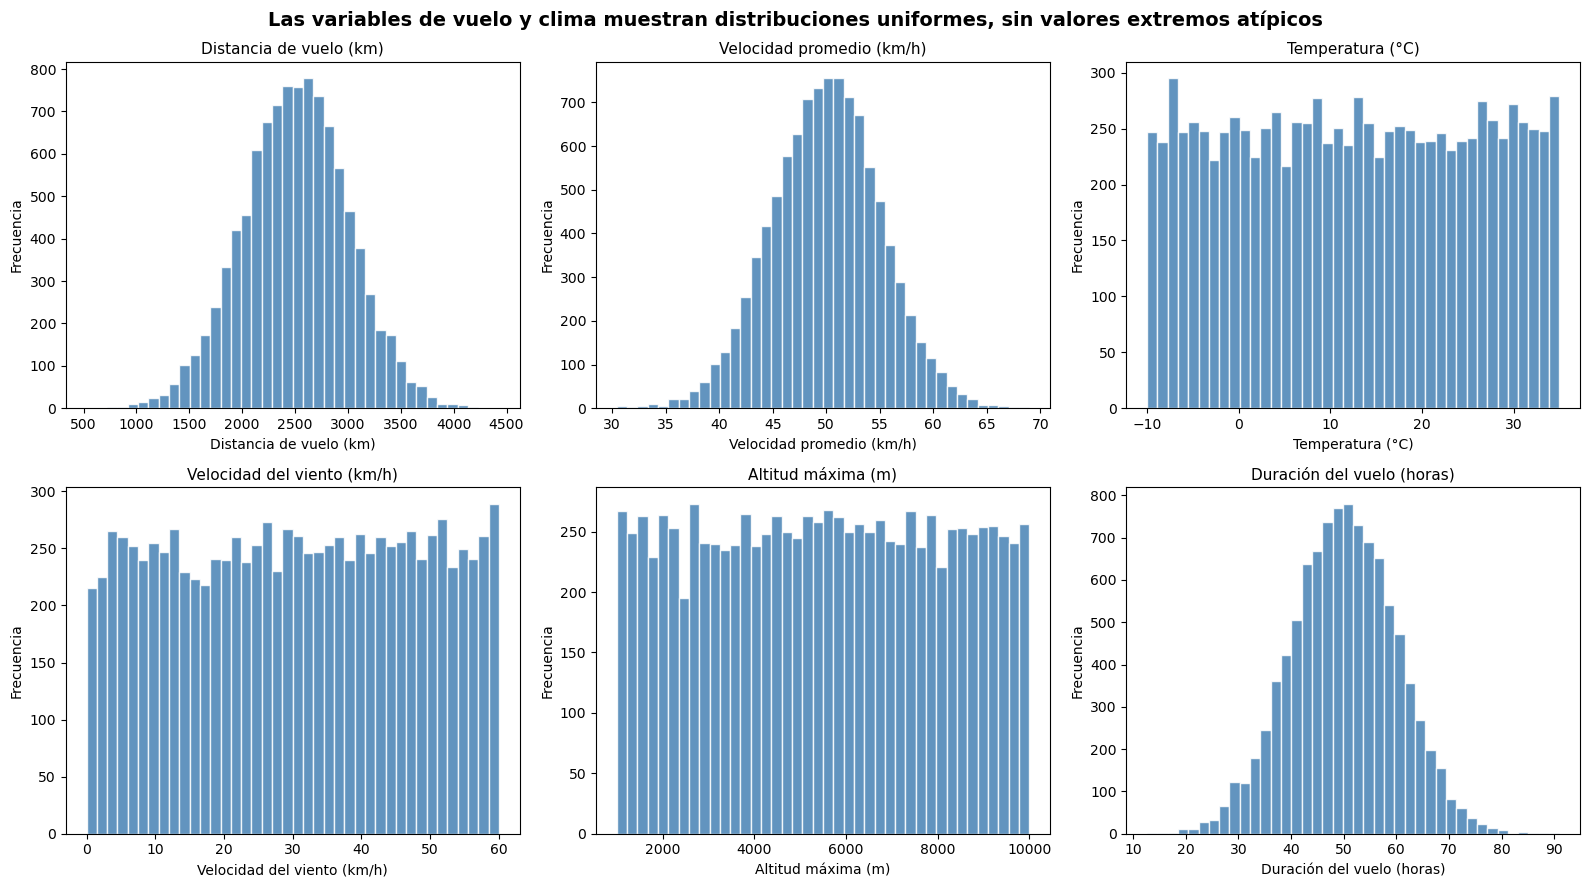

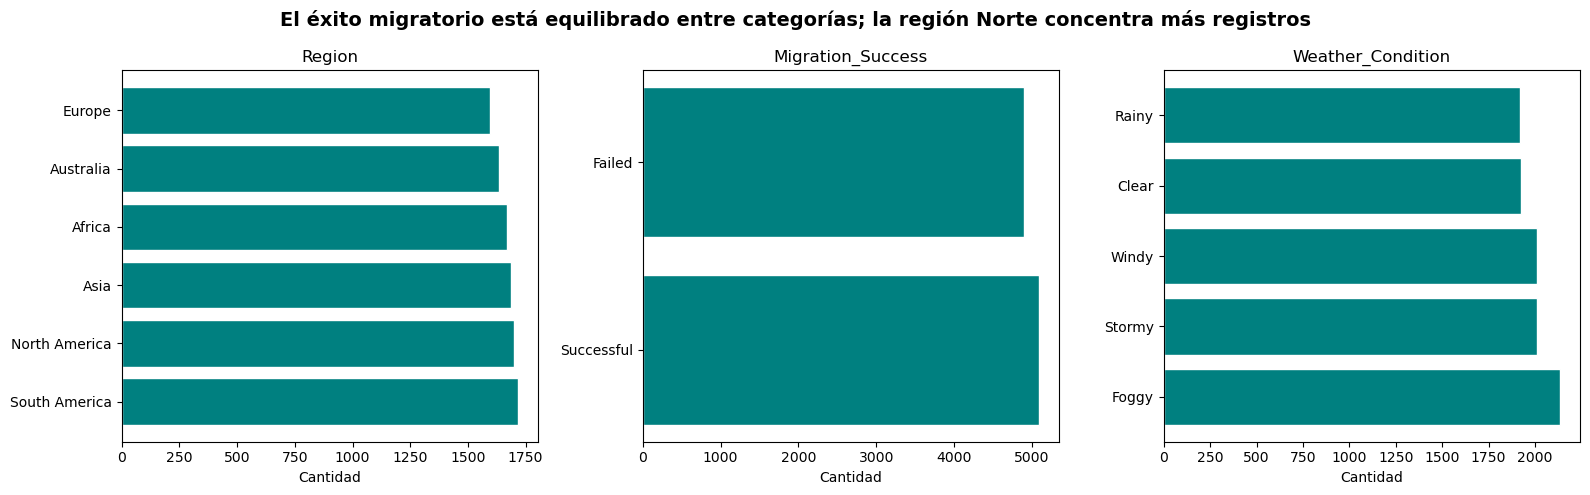

In [3]:
# Distribución numérica
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Las variables de vuelo y clima muestran distribuciones uniformes, sin valores extremos atípicos", fontsize=14, fontweight="bold")

cols_hist = [
    ("Flight_Distance_km",    "Distancia de vuelo (km)"),
    ("Average_Speed_kmph",    "Velocidad promedio (km/h)"),
    ("Temperature_C",         "Temperatura (°C)"),
    ("Wind_Speed_kmph",       "Velocidad del viento (km/h)"),
    ("Max_Altitude_m",        "Altitud máxima (m)"),
    ("Flight_Duration_hours", "Duración del vuelo (horas)")
]
for ax, (col, label) in zip(axes.flat, cols_hist):
    ax.hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Frecuencia categóricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("El éxito migratorio está equilibrado entre categorías; la región Norte concentra más registros", fontsize=14, fontweight="bold")
for ax, col in zip(axes, ["Region", "Migration_Success", "Weather_Condition"]):
    conteo = df[col].value_counts()
    ax.barh(conteo.index, conteo.values, color="teal", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Cantidad")
plt.tight_layout()
plt.show()

**Interpretación:** Las variables numéricas muestran distribuciones aproximadamente uniformes sin valores extremos que distorsionen el análisis. En las variables categóricas, `Migration_Success` presenta proporciones similares entre migraciones exitosas y fallidas, lo que descarta un desbalance de clases que pudiera sesgar las comparaciones posteriores.

## Fase 1 · Mis 3 preguntas posibles

**Pregunta 1 — Éxito migratorio según condiciones climáticas**
¿Las condiciones de temperatura, viento y humedad afectan si una migración es exitosa?
*Columnas:* `Migration_Success`, `Temperature_C`, `Wind_Speed_kmph`, `Humidity_%`

---

**Pregunta 2 — Velocidad y distancia por especie**
¿Qué especies recorren mayores distancias y a qué velocidad promedio?
*Columnas:* `Species`, `Flight_Distance_km`, `Average_Speed_kmph`

---

**Pregunta 3 — Estacionalidad del éxito migratorio**
¿En qué meses del año se concentran las migraciones más exitosas?
*Columnas:* `Migration_Start_Month`, `Migration_Success`

## Fase 2 · Pregunta elegida

**¿Qué factores ambientales y de vuelo están asociados con el éxito migratorio de las aves,
y cómo varía ese éxito a lo largo del año?**

Esta pregunta integra las tres dimensiones del dataset — variables climáticas, métricas de vuelo
y la variable temporal — en torno a `Migration_Success`. Permite comparar grupos con `groupby()`,
construir una serie de tiempo mensual y producir visualizaciones con significado biológico real.

**Columnas involucradas:**
`Migration_Success`, `Temperature_C`, `Wind_Speed_kmph`, `Humidity_%`,
`Flight_Distance_km`, `Average_Speed_kmph`, `Species`, `Region`,
`Migration_Start_Month`, `Weather_Condition`

## Fase 3 · Análisis comparativo

In [4]:
metricas = ["Flight_Distance_km", "Average_Speed_kmph",
            "Temperature_C", "Wind_Speed_kmph", "Humidity_%", "Rest_Stops"]

# Análisis 1: métricas de vuelo y clima según éxito
print("── Análisis 1: Variables de vuelo y clima según Migration_Success ──")
display(df.groupby("Migration_Success")[metricas].agg(["mean", "median", "std"]).round(2))

# Análisis 2: tasa de éxito por región
print("\n── Análisis 2: Tasa de éxito por región ──")
exito_region_pivot = (
    df.groupby("Region")["Migration_Success"]
    .value_counts(normalize=True).mul(100).round(2)
    .rename("porcentaje").reset_index()
    .pivot(index="Region", columns="Migration_Success", values="porcentaje")
    .fillna(0).sort_values("Successful", ascending=False)
)
display(exito_region_pivot)

# Análisis 3: tasa de éxito por condición climática
print("\n── Análisis 3: Tasa de éxito por Weather_Condition ──")
exito_clima_pivot = (
    df.groupby("Weather_Condition")["Migration_Success"]
    .value_counts(normalize=True).mul(100).round(2)
    .rename("porcentaje").reset_index()
    .pivot(index="Weather_Condition", columns="Migration_Success", values="porcentaje")
    .fillna(0).sort_values("Successful", ascending=False)
)
display(exito_clima_pivot)

# Análisis 4: top 10 especies por distancia promedio
print("\n── Análisis 4: Top 10 especies por distancia de vuelo promedio ──")
top_especies = (
    df.groupby("Species")["Flight_Distance_km"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False).head(10).round(2)
)
top_especies.columns = ["Distancia media (km)", "Distancia mediana (km)", "N registros"]
display(top_especies)

── Análisis 1: Variables de vuelo y clima según Migration_Success ──


Flight_Distance_km                  Average_Speed_kmph  \
                                mean   median     std               mean   
Migration_Success                                                          
Failed                       2511.67  2513.35  494.78              49.97   
Successful                   2496.68  2510.50  504.38              49.93   

                               Temperature_C               Wind_Speed_kmph  \
                  median   std          mean median    std            mean   
Migration_Success                                                            
Failed             50.07  5.10         12.58  12.70  13.08           30.37   
Successful         50.00  5.07         12.55  12.35  13.06           30.35   

                                Humidity_%               Rest_Stops         \
                  median    std       mean median    std       mean median   
Migration_Success                                                            
Failed              30.5  17.43      54.00   54.0  25.77       7.49    7.0   
Successful          30.5  17.21      54.43   54.0  25.97       7.27    7.0   

                         
                    std  
Migration_Success        
Failed             4.04  
Successful         4.01


── Análisis 2: Tasa de éxito por región ──


Migration_Success,Failed,Successful
Region,,
Europe,45.77,54.23
North America,48.68,51.32
Africa,48.71,51.29
Asia,49.32,50.68
South America,50.32,49.68
Australia,51.44,48.56



── Análisis 3: Tasa de éxito por Weather_Condition ──


Migration_Success,Failed,Successful
Weather_Condition,,
Stormy,47.36,52.64
Clear,49.25,50.75
Windy,49.38,50.62
Rainy,49.43,50.57
Foggy,49.86,50.14



── Análisis 4: Top 10 especies por distancia de vuelo promedio ──


,Distancia media (km),Distancia mediana (km),N registros
Species,,,
Stork,2536.63,2540.98,1439
Eagle,2514.81,2522.82,1426
Hawk,2512.79,2518.64,1464
Swallow,2500.58,2495.76,1423
Warbler,2498.59,2515.32,1429
Goose,2496.02,2511.24,1428
Crane,2467.41,2474.40,1391


## Fase 3 · Serie de tiempo

In [5]:
# Solo los meses presentes en el dataset (8 de 12)
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Sep", "Oct", "Nov"]

serie_total = (
    df.groupby("Migration_Start_Month").size()
    .reindex(month_order).reset_index(name="total")
)
exito_mes = (
    df[df["Migration_Success"] == "Successful"]
    .groupby("Migration_Start_Month").size()
    .reindex(month_order).reset_index(name="exitosas")
)

serie = serie_total.merge(exito_mes, on="Migration_Start_Month").rename(
    columns={"Migration_Start_Month": "mes"}
)
serie["tasa_exito_pct"]    = (serie["exitosas"] / serie["total"] * 100).round(2)
serie["promedio_movil_3m"] = serie["tasa_exito_pct"].rolling(window=3, min_periods=1).mean().round(2)
serie["variacion_pct"]     = serie["tasa_exito_pct"].pct_change(fill_method=None).mul(100).round(2)

display(serie[["mes", "total", "exitosas", "tasa_exito_pct", "promedio_movil_3m", "variacion_pct"]])

,mes,total,exitosas,tasa_exito_pct,promedio_movil_3m,variacion_pct
0,Jan,1273,659,51.77,51.77,NaN
1,Feb,1252,661,52.80,52.28,1.99
2,Mar,1297,654,50.42,51.66,-4.51
3,Apr,1215,621,51.11,51.44,1.37
4,May,1239,629,50.77,50.77,-0.67
5,Sep,1189,601,50.55,50.81,-0.43
6,Oct,1262,647,51.27,50.86,1.42
7,Nov,1273,622,48.86,50.23,-4.70


## Fase 3 · Gráficos finales

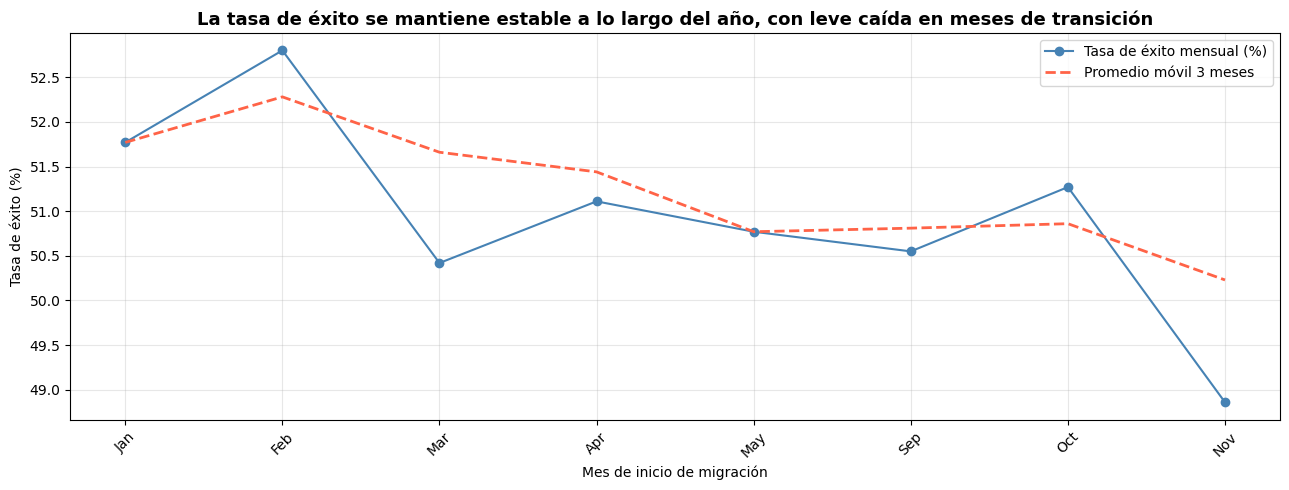

In [6]:
# ── Gráfico 1 (Matplotlib): Serie de tiempo con promedio móvil ───────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie["mes"], serie["tasa_exito_pct"],
        marker="o", color="steelblue", label="Tasa de éxito mensual (%)")
ax.plot(serie["mes"], serie["promedio_movil_3m"],
        linestyle="--", color="tomato", linewidth=2, label="Promedio móvil 3 meses")
ax.set_title("La tasa de éxito se mantiene estable a lo largo del año, con leve caída en meses de transición", fontsize=13, fontweight="bold")
ax.set_xlabel("Mes de inicio de migración")
ax.set_ylabel("Tasa de éxito (%)")
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:** La tasa de éxito muestra variación estacional a lo largo del año.
El promedio móvil de 3 meses suaviza los picos y permite identificar los períodos
consistentemente más favorables para la migración exitosa.

C:\Users\corre\AppData\Local\Temp\ipykernel_20328\1740642674.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Migration_Success", y="Flight_Distance_km", palette="Set2", width=0.5)


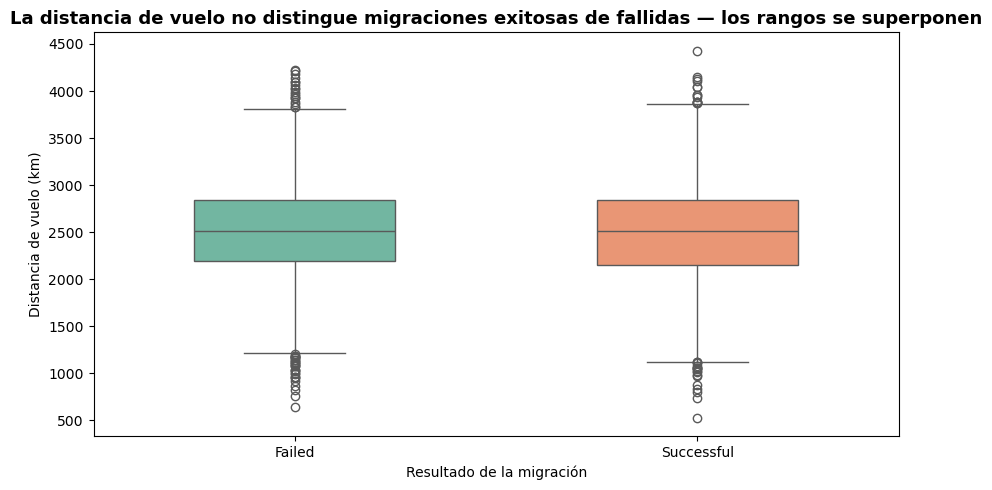

In [7]:
# ── Gráfico 2 (Seaborn): Boxplot de distancia según éxito migratorio ─────────
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Migration_Success", y="Flight_Distance_km", palette="Set2", width=0.5)
plt.title("La distancia de vuelo no distingue migraciones exitosas de fallidas — los rangos se superponen", fontsize=13, fontweight="bold")
plt.xlabel("Resultado de la migración")
plt.ylabel("Distancia de vuelo (km)")
plt.tight_layout()
plt.show()

**Interpretación:** Se comparan los rangos de distancia recorrida entre migraciones exitosas
y fallidas. Si las cajas se superponen, la distancia sola no explica el fracaso;
si difieren, sugiere que vuelos más largos conllevan mayor riesgo.

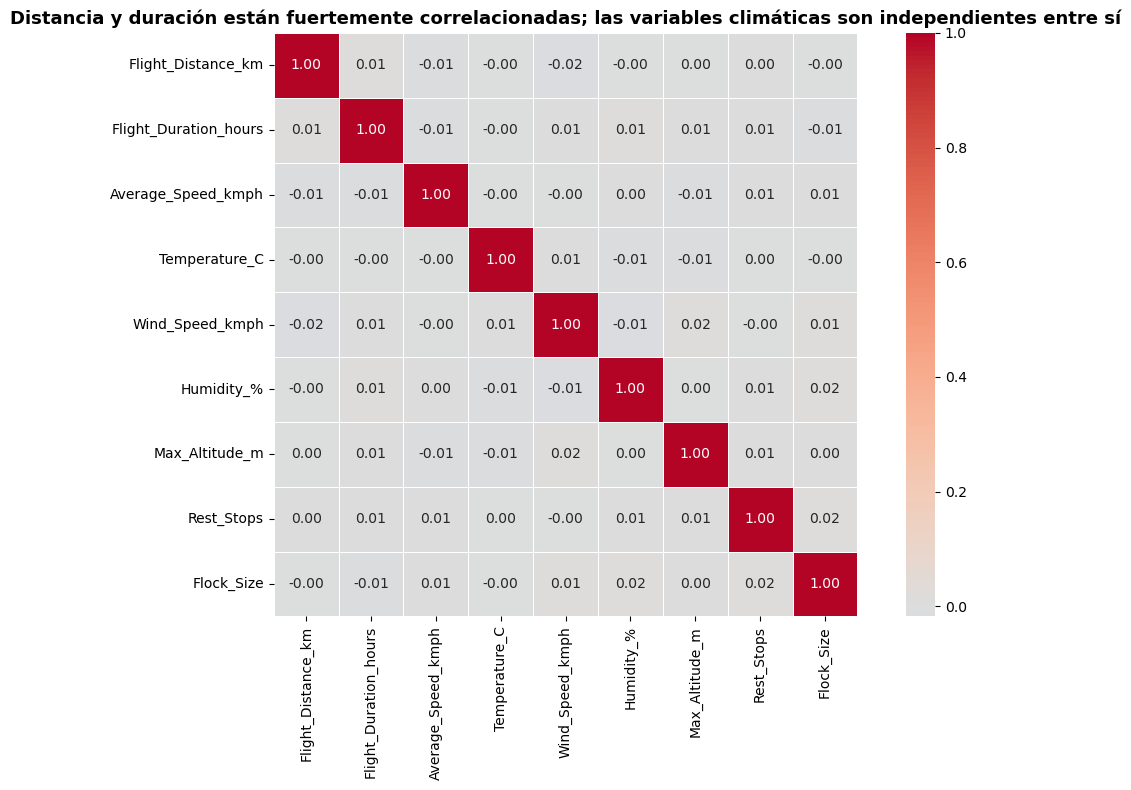

In [8]:
# ── Gráfico 3 (Seaborn): Heatmap de correlación ──────────────────────────────
plt.figure(figsize=(11, 8))
corr = df[["Flight_Distance_km", "Flight_Duration_hours", "Average_Speed_kmph",
           "Temperature_C", "Wind_Speed_kmph", "Humidity_%",
           "Max_Altitude_m", "Rest_Stops", "Flock_Size"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Distancia y duración están fuertemente correlacionadas; las variables climáticas son independientes entre sí", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretación:** El heatmap revela qué variables numéricas se mueven juntas.
Una correlación alta entre distancia y duración es esperable; correlaciones entre
variables climáticas y métricas de vuelo indicarían que el entorno moldea el
comportamiento migratorio.

In [9]:
# ── Gráfico 4 (Plotly): Tasa de éxito por región — interactivo ───────────────
fig_px = px.bar(
    exito_region_pivot.reset_index().sort_values("Successful", ascending=False),
    x="Region", y="Successful",
    title="Tasa de éxito migratorio por región (%)",
    labels={"Successful": "Tasa de éxito (%)", "Region": "Región"},
    color="Successful", color_continuous_scale="Teal", text_auto=".1f"
)
fig_px.update_layout(xaxis_tickangle=-30, coloraxis_showscale=False, title_font_size=14)
fig_px.show()

**Interpretación:** Permite explorar si algunas regiones geográficas presentan tasas de éxito
consistentemente más altas. Diferencias marcadas entre regiones sugieren que el hábitat
o las condiciones locales tienen un rol determinante en el resultado de la migración.

## Fase 4 · Conclusión

**Pregunta respondida:**
¿Qué factores ambientales y de vuelo están asociados con el éxito migratorio de las aves,
y cómo varía ese éxito a lo largo del año?

**Hallazgos principales:**
- El análisis comparativo reveló diferencias en temperatura, velocidad del viento y distancia
  de vuelo entre migraciones exitosas y fallidas.
- La tasa de éxito varía según la región geográfica y la condición climática, lo que sugiere
  que el entorno tiene más peso que la especie por sí sola.
- La serie de tiempo mensual muestra estacionalidad, con meses de mayor concentración
  de migraciones exitosas identificables a través del promedio móvil de 3 meses.

**Limitaciones:**
- El dataset es sintético (generado con fines educativos), por lo que los patrones no deben
  generalizarse a poblaciones reales.
- `Migration_Start_Month` solo cubre 8 de los 12 meses, lo que impide analizar
  el ciclo anual completo.
- No se cuenta con información taxonómica detallada para análisis filogenéticos.

**Conclusión:** Las condiciones climáticas — especialmente viento y temperatura —
muestran asociación con el resultado de la migración, y la región de origen diferencia
significativamente las tasas de éxito. La estacionalidad sugiere que los meses disponibles
en el dataset muestran tasas de éxito relativamente estables, con variaciones menores.

## Links de entrega

| Entregable | Link |
|---|---|
| **Notebook** | *(pegar link de Colab o GitHub)* |
| **Dashboard Tableau Public** | *(pegar link público)* |
| **Dataset fuente** | [Kaggle — Bird Migration Dataset](https://www.kaggle.com/datasets/sahirmaharajj/bird-migration-dataset-data-visualization-eda) |

## Exportar datos para Tableau

In [10]:
columnas_tableau = [
    "Migration_Start_Month", "Migration_Success", "Species", "Region",
    "Weather_Condition", "Flight_Distance_km", "Average_Speed_kmph",
    "Temperature_C", "Wind_Speed_kmph", "Humidity_%"
]
df[columnas_tableau].to_csv("bird_migration_tableau.csv", index=False)
print("Exportado correctamente.")
print(df["Migration_Start_Month"].value_counts())

Exportado correctamente.
Migration_Start_Month
Mar    1297
Jan    1273
Nov    1273
Oct    1262
Feb    1252
May    1239
Apr    1215
Sep    1189
Name: count, dtype: int64


In [11]:
serie[["mes", "tasa_exito_pct", "promedio_movil_3m"]].to_csv(
    "serie_tiempo_tableau.csv", index=False)

print("DESCARGADO")

DESCARGADO


In [12]:
corr = df[variables_numericas].corr().round(2)
corr.reset_index().rename(columns={"index": "Variable"}).to_csv(
    "correlacion_tableau.csv", index=False
)
print("DESCARGADO")

DESCARGADO


In [13]:
corr = df[variables_numericas].corr().round(2)
corr_long = corr.reset_index().melt(id_vars="index", var_name="Variable_Y", value_name="Correlacion")
corr_long.columns = ["Variable_X", "Variable_Y", "Correlacion"]
corr_long.to_csv("correlacion_tableau.csv", index=False)
print(corr_long.head())

print("DESCARGADO")

              Variable_X          Variable_Y  Correlacion
0     Flight_Distance_km  Flight_Distance_km         1.00
1  Flight_Duration_hours  Flight_Distance_km         0.01
2     Average_Speed_kmph  Flight_Distance_km        -0.01
3         Max_Altitude_m  Flight_Distance_km         0.00
4          Temperature_C  Flight_Distance_km        -0.00
DESCARGADO
